#Debug de pipes para el entrenamiento

In [1]:
%cd /home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo

/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo


In [2]:
from gerumo import *
import json
from ctapipe.instrument import CameraGeometry
import numpy as np
from astropy import units

/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/raw/MST_NectarCam.npy not found.
File ML1/raw/MST_NectarCam not found
/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/simple/MST_NectarCam.npy not found.
File ML1/simple/MST_NectarCam not found
/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/simple_shift/MST_NectarCam.npy not found.
File ML1/simple_shift/MST_NectarCam not found
/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/time/MST_NectarCam.npy not found.
File ML1/time/MST_NectarCam not found
/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/time_shift/MST_NectarCam.npy not found.
File ML1/time_shift/MST_NectarCam not found
/home

2026-04-29 18:22:14.051306: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 18:22:14.075985: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-29 18:22:14.076013: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-29 18:22:14.076667: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-29 18:22:14.081121: I tensorflow/core/platform/cpu_feature_guar

In [3]:
config_path = "/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/train/config/local/alt_az/umonna_LST.json"
with open(config_path) as cfg_file:
    config = json.load(cfg_file)

In [4]:
telescope = config["telescope"]
version = config["version"]
preprocessing_parameters = config.get("preprocessing", {})
camera_parameters = preprocessing_parameters["CameraPipe"]
train_events_csv    = config["train_events_csv"]
train_telescope_csv = config["train_telescope_csv"]
replace_folder_train = config["replace_folder_train"]
min_observations = config["min_observations"]
targets = config["targets"]
target_mode = config["target_mode"]
input_image_mode = config["input_image_mode"]
input_image_mask = config["input_image_mask"]
input_features = config["input_features"]

target_mode_config = get_target_mode_config(config, target_mode)
target_domains_list = target_mode_config["target_domains"]

target_domains = {target: target_domain for target, target_domain in zip(targets, target_domains_list)}

In [5]:
train_dataset = load_dataset(train_events_csv, train_telescope_csv, replace_folder_train)
train_dataset = aggregate_dataset(train_dataset, az=True, log10_mc_energy=True)
train_dataset = filter_dataset(train_dataset, version, telescope, min_observations, target_domains)

In [6]:
print(type(train_dataset))
print(train_dataset.keys())
print(train_dataset.iloc[0])

<class 'pandas.core.frame.DataFrame'>
Index(['event_unique_id', 'event_id', 'source', 'folder', 'core_x', 'core_y',
       'h_first_int', 'alt', 'az', 'mc_energy', 'telescope_id', 'image_index',
       'type', 'x', 'y', 'z', 'observation_indice', 'log10_mc_energy',
       'hdf5_filepath'],
      dtype='object')
event_unique_id                                          5829_2470608_0
event_id                                                        2470608
source                              gamma-diffuse_with_images_00.dl2.h5
folder                /home/sven-klein-plarre/Documentos/Universidad...
core_x                                                      -116.570282
core_y                                                        95.179245
h_first_int                                                20108.664062
alt                                                            1.229731
az                                                             0.098305
mc_energy                              

In [7]:
batch_dataset = train_dataset.iloc[0:19]

In [8]:
camera_pipe = CameraPipe(telescope_type=telescope, version=version, **camera_parameters)
cameras = load_cameras(batch_dataset, version=version)
telescope_types = ["LST"]*len(batch_dataset)

/home/sven-klein-plarre/anaconda3/envs/gerumo_py_3_10/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.0.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
MST_flash = load_camera_geometry("MST_NectarCam","DL1")
LST_flash = load_camera_geometry("LST_LSTCam","DL1")
geometry = CameraGeometry.from_name("NectarCam")

In [ ]:
cam = camera_pipe(cameras)

In [ ]:
a = cam[0][0]

In [ ]:
pix_L = PIXELS_POSITION[version]["simple_shift"]["LST_LSTCam"]
print("X_left: ",min(pix_L[0]), ", ", max(pix_L[0]))
print("X_right: ", min(pix_L[1]), ", ", max(pix_L[1]))
print("Y: ", min(pix_L[2]), ", ", max(pix_L[2]))

X_left:  0 ,  46
X_right:  0 ,  46
Y:  0 ,  54


In [ ]:
#x_left, x_right, y
pix = PIXELS_POSITION[version]["simple_shift"][telescope]
print("X_left: ",min(pix[0]), ", ", max(pix[0]))
print("X_right: ", min(pix[1]), ", ", max(pix[1]))
print("Y: ", min(pix[2]), ", ", max(pix[2]))

X_left:  0 ,  46
X_right:  0 ,  46
Y:  0 ,  54


In [ ]:
img = cameras_to_images(cameras, telescope_types, input_image_mode, input_image_mask, version=version)

In [ ]:
test_b_dataset = batch_dataset[input_features]
#t_b_d_2 = scaler.transfrm(test_b_dataset)
print(type(test_b_dataset))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
b = [img, test_b_dataset]

In [ ]:
print(type(b[0]),type(b[1]))
print(b[1]["y"])

<class 'list'> <class 'pandas.core.frame.DataFrame'>
1    -52.070000
2     66.139999
3     50.490002
4    -64.540001
10   -64.540001
11    50.490002
15    66.139999
16   -52.070000
48    50.490002
49    66.139999
57   -64.540001
58   -52.070000
75   -64.540001
76    50.490002
77    66.139999
78   -52.070000
80    66.139999
81    50.490002
86   -64.540001
Name: y, dtype: float64


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-04-28 00:05:41.693400: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcuda.so.1
2026-04-28 00:05:41.748722: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-28 00:05:41.754212: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1555] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA GeForce RTX 3050 Laptop GPU computeCapability: 8.6
coreClock: 1.74GHz coreCount: 16 deviceMemorySize: 3.68GiB deviceMemoryBandwidth: 178.84GiB/s
2026-04-28 00:05:41.757401: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudart.so.10.1
2026-04-28 00:05:41.794673: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2026-04-28 00:05:41.829971: I tensorflow/stream_ex

Prueba de version nueva de load_camera_geometry

In [ ]:
charge, peak = cameras[0]

In [ ]:
def load_camera_geometry_new(telescope_type, version="ML1"):
    pixpos = PIXELS_POSITION[version]['raw'][telescope_type]
    n_pix = len(pixpos[0])
    geometry = CameraGeometry(
        camera_name= TELESCOPE_CAMERA[telescope_type],
        pix_id= np.arange(n_pix),
        pix_x = units.quantity.Quantity(pixpos[0], 'meter'),
        pix_y = units.quantity.Quantity(pixpos[1], 'meter'),
        pix_area= units.quantity.Quantity(np.full(n_pix,0.002079326892271638),'m2'),
        pix_type= "hexagonal"
    )
    return geometry

In [ ]:
geo_new = load_camera_geometry_new(telescope,version)
geo_old = load_camera_geometry(telescope,version)

In [ ]:
from ctapipe.image import tailcuts_clean, dilate

def apply_cleaning(geometry, charge, peak, boundary_thresh, picture_thresh):
    charge_c = charge.copy()
    peak_c = peak.copy()

    mask = tailcuts_clean(geometry, charge_c, picture_thresh, boundary_thresh)

    charge_c[~mask] = 0.0

    for _ in range(3):
        mask = dilate(geometry, mask)

    peak_c[~mask] = 0.0

    return mask, charge_c, peak_c

In [ ]:
mask_old, charge_old, peak_old = apply_cleaning(
    geo_old, charge, peak, 6, 14
)

mask_new, charge_new, peak_new = apply_cleaning(
    geo_new, charge, peak, 6, 14
)

In [ ]:
import matplotlib.pyplot as plt

def plot_camera(geom, values, title):
    plt.figure(figsize=(5,5))
    plt.scatter(
        geom.pix_x.value,
        geom.pix_y.value,
        c=values,
        s=10,
    )
    plt.colorbar()
    plt.title(title)
    plt.axis('equal')
    plt.show()

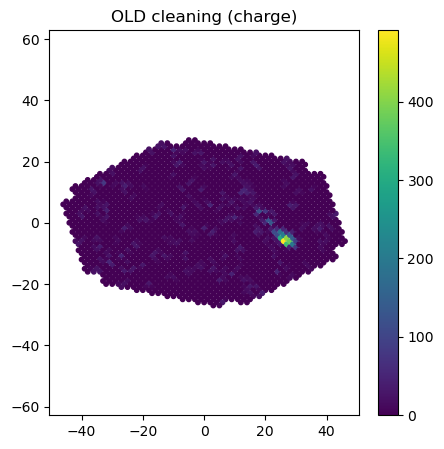

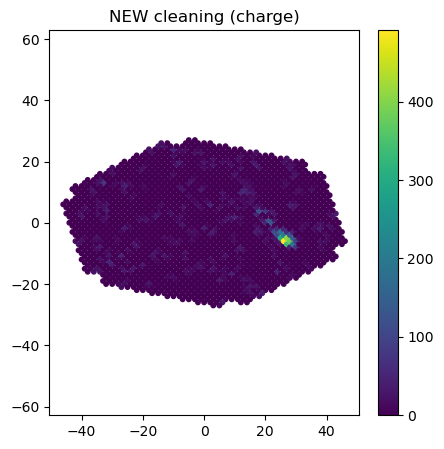

In [ ]:
plot_camera(geo_old, charge_old, "OLD cleaning (charge)")
plot_camera(geo_new, charge_new, "NEW cleaning (charge)")

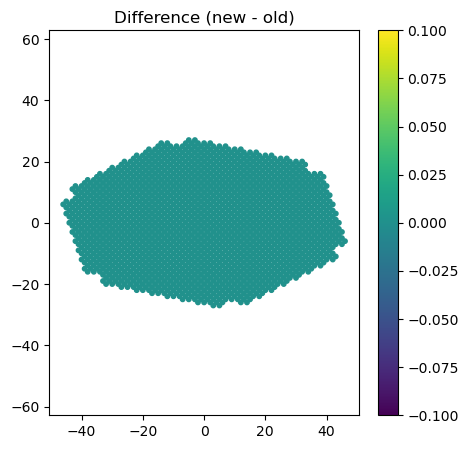

In [ ]:
diff = charge_new - charge_old
plot_camera(geo_new, diff, "Difference (new - old)")

In [ ]:
print("Pixels different in mask:",
      np.sum(mask_old != mask_new))

print("Charge difference (L1):",
      np.sum(np.abs(charge_old - charge_new)))

print("Charge difference (mean):",
      np.mean(np.abs(charge_old - charge_new)))

Pixels different in mask: 0
Charge difference (L1): 0
Charge difference (mean): 0.0
